# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Student Placement Sallary Dataset](https://www.kaggle.com/datasets/amaymishra11/student-placement-and-salary-dataset-skills-based)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/amaymishra11/student-placement-and-salary-dataset-skills-based/student_placement_salary_elite_v2.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('student_placement_salary_elite_v2.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,MNC,Software Engineer,63.55
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,MNC,Data Scientist,75.17
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,MNC,Software Engineer,80.44
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,83.6,0,6,0,74.3,2,1,MNC,Software Engineer,72.11
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,86.3,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05


## last Five row

In [4]:
df.tail()

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
8995,S8995,6.51,IT,2,1,0,0,1,56.6,8.2,43.2,0,2,0,50.1,2,1,MNC,Analyst,75.29
8996,S8996,7.74,IT,3,1,1,1,0,67.9,6.3,49.4,0,2,0,57.6,3,1,MNC,Analyst,69.30
8997,S8997,7.14,CSE,3,1,0,1,1,40.4,8.0,67.4,1,1,0,65.8,3,1,MNC,Data Scientist,85.58
8998,S8998,5.21,IT,1,1,0,0,1,79.9,6.3,77.2,1,6,0,78.9,2,1,Mid-size,Software Engineer,54.54
8999,S8999,6.05,Civil,2,1,1,0,0,80.0,6.0,79.1,0,2,0,49.2,2,1,MNC,Software Engineer,84.32


## Shape of our dataset

In [5]:
df.shape

(9000, 20)

## List out all columns

In [6]:
df.columns

Index(['student_id', 'cgpa', 'branch', 'college_tier', 'python_skill',
       'dsa_skill', 'ml_skill', 'web_dev_skill', 'coding_score',
       'communication_score', 'aptitude_score', 'internships', 'projects',
       'backlogs', 'resume_score', 'skill_score', 'placed', 'company_type',
       'job_role', 'salary_lpa'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

student_id              object
cgpa                   float64
branch                  object
college_tier             int64
python_skill             int64
dsa_skill                int64
ml_skill                 int64
web_dev_skill            int64
coding_score           float64
communication_score    float64
aptitude_score         float64
internships              int64
projects                 int64
backlogs                 int64
resume_score           float64
skill_score              int64
placed                   int64
company_type            object
job_role                object
salary_lpa             float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           9000 non-null   object 
 1   cgpa                 9000 non-null   float64
 2   branch               9000 non-null   object 
 3   college_tier         9000 non-null   int64  
 4   python_skill         9000 non-null   int64  
 5   dsa_skill            9000 non-null   int64  
 6   ml_skill             9000 non-null   int64  
 7   web_dev_skill        9000 non-null   int64  
 8   coding_score         9000 non-null   float64
 9   communication_score  9000 non-null   float64
 10  aptitude_score       9000 non-null   float64
 11  internships          9000 non-null   int64  
 12  projects             9000 non-null   int64  
 13  backlogs             9000 non-null   int64  
 14  resume_score         9000 non-null   float64
 15  skill_score          9000 non-null   i

## Check Null Value

In [9]:
df.isnull().sum()

student_id                0
cgpa                      0
branch                    0
college_tier              0
python_skill              0
dsa_skill                 0
ml_skill                  0
web_dev_skill             0
coding_score              0
communication_score       0
aptitude_score            0
internships               0
projects                  0
backlogs                  0
resume_score              0
skill_score               0
placed                    0
company_type           1298
job_role               1298
salary_lpa                0
dtype: int64

# Drop Most Null Value Column

In [10]:
df.drop(columns=['company_type', 'job_role'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,cgpa,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,salary_lpa
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,7.507213,2.011778,0.650111,0.555556,0.299778,0.393444,49.783567,6.991267,70.125711,1.032000,3.500556,0.421333,67.785989,1.898889,0.855778,55.409311
std,1.446496,0.818224,0.476961,0.496932,0.458186,0.488541,28.891340,1.717548,17.475032,0.966191,1.707595,0.747207,17.058188,0.953059,0.351334,27.673531
min,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,40.000000,0.000000,1.000000,0.000000,16.500000,0.000000,0.000000,0.000000
25%,6.257500,1.000000,0.000000,0.000000,0.000000,0.000000,24.900000,5.500000,54.800000,0.000000,2.000000,0.000000,55.900000,1.000000,1.000000,43.427500
50%,7.500000,2.000000,1.000000,1.000000,0.000000,0.000000,49.600000,7.000000,70.300000,1.000000,4.000000,0.000000,67.400000,2.000000,1.000000,60.100000
75%,8.750000,3.000000,1.000000,1.000000,1.000000,1.000000,74.625000,8.500000,85.400000,2.000000,5.000000,1.000000,79.000000,3.000000,1.000000,75.380000
max,10.000000,3.000000,1.000000,1.000000,1.000000,1.000000,100.000000,10.000000,100.000000,3.000000,6.000000,3.000000,132.100000,4.000000,1.000000,129.430000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

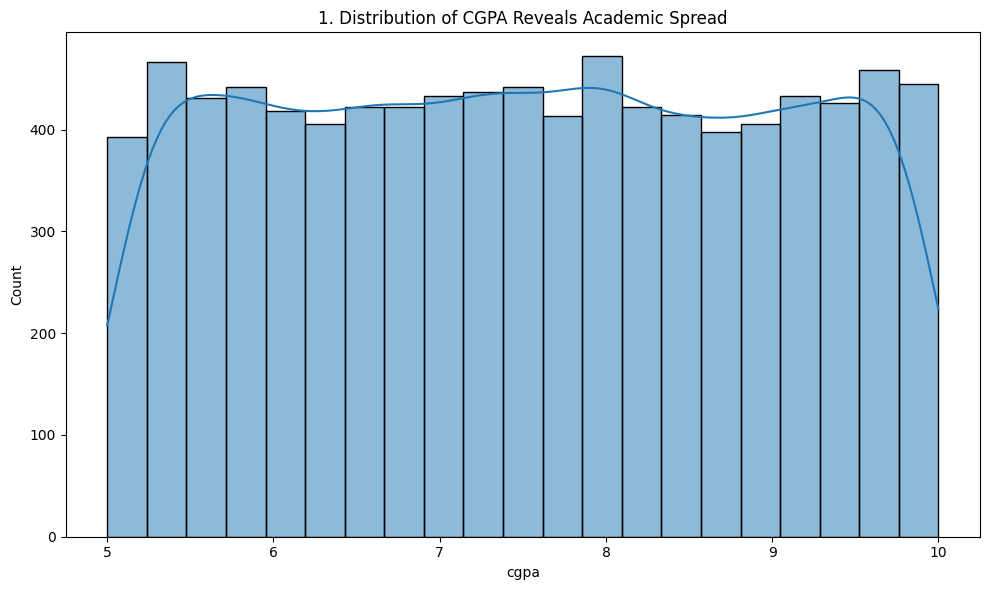

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['cgpa'], kde=True)
plt.title(f'{plot_no}. Distribution of CGPA Reveals Academic Spread')
show_fig()
plot_no += 1

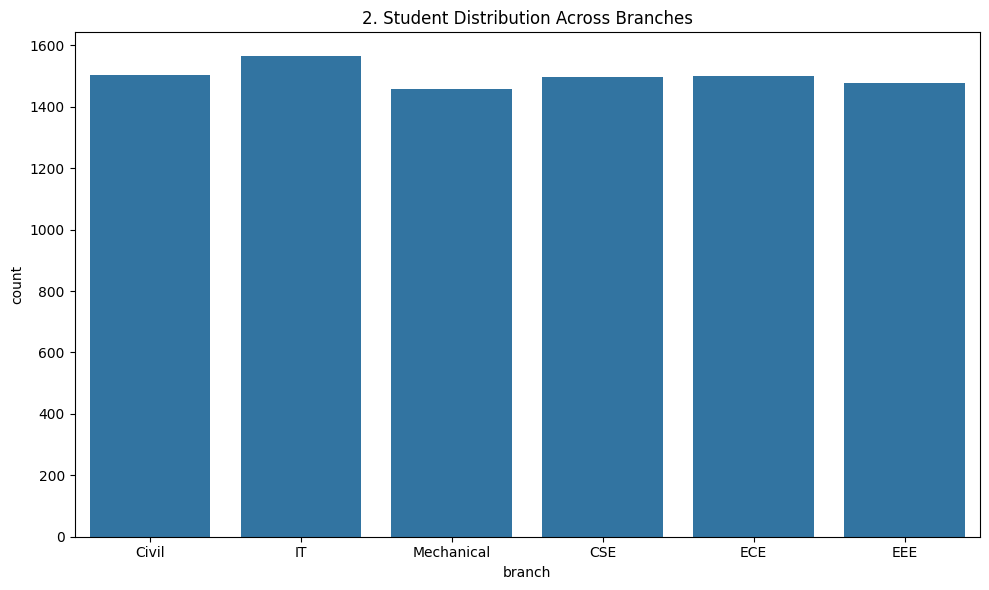

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='branch', data=df)
plt.title(f'{plot_no}. Student Distribution Across Branches')
show_fig()
plot_no += 1

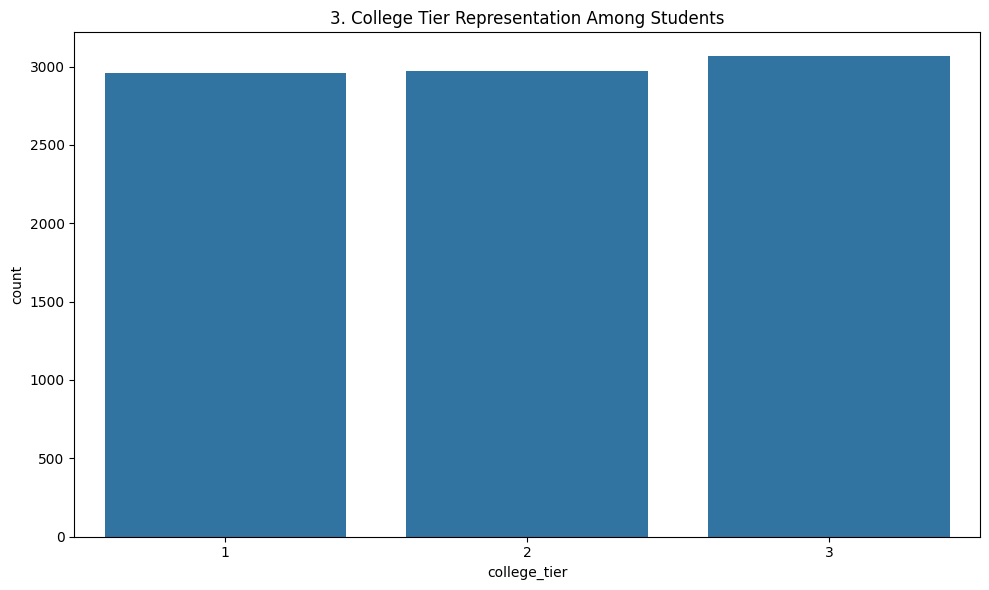

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='college_tier', data=df)
plt.title(f'{plot_no}. College Tier Representation Among Students')
show_fig()
plot_no += 1

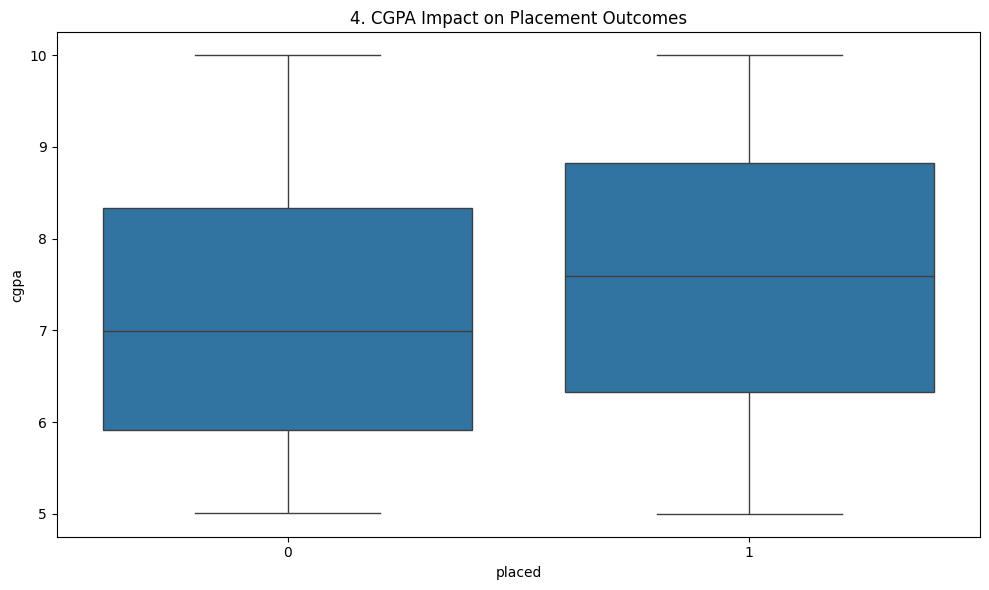

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='placed', y='cgpa', data=df)
plt.title(f'{plot_no}. CGPA Impact on Placement Outcomes')
show_fig()
plot_no += 1

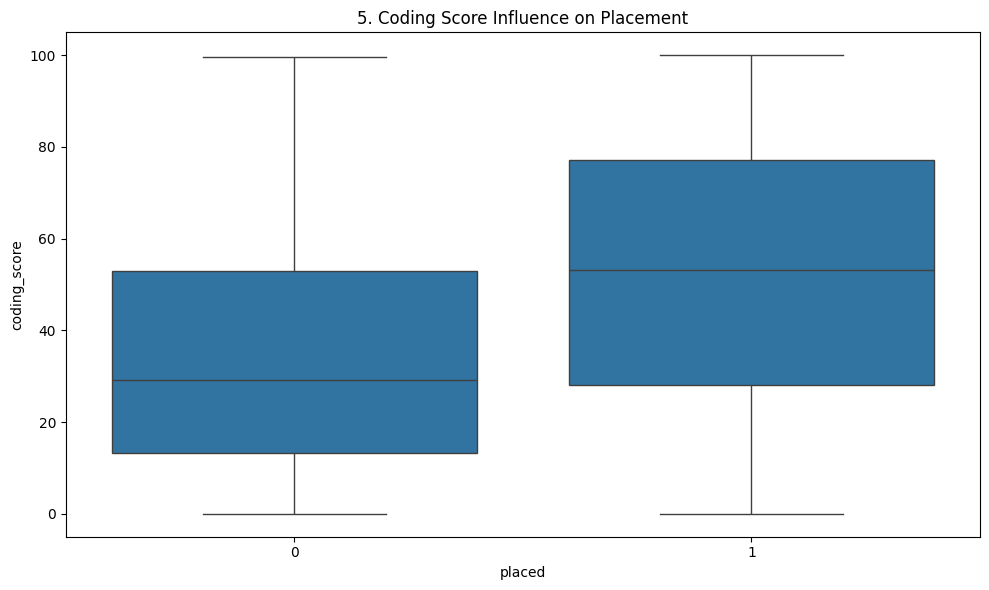

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='placed', y='coding_score', data=df)
plt.title(f'{plot_no}. Coding Score Influence on Placement')
show_fig()
plot_no += 1

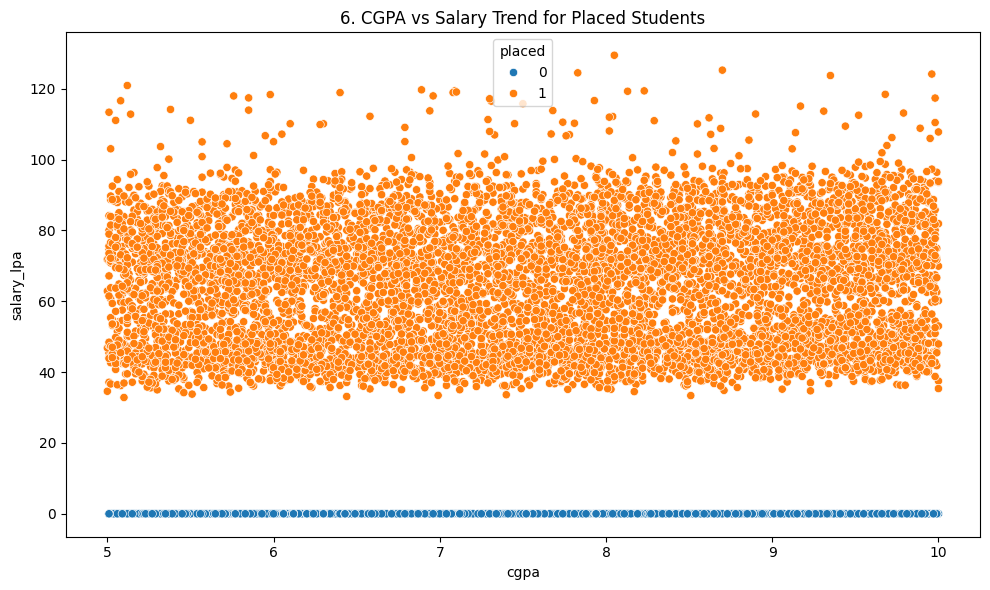

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='cgpa', y='salary_lpa', hue='placed', data=df)
plt.title(f'{plot_no}. CGPA vs Salary Trend for Placed Students')
show_fig()
plot_no += 1

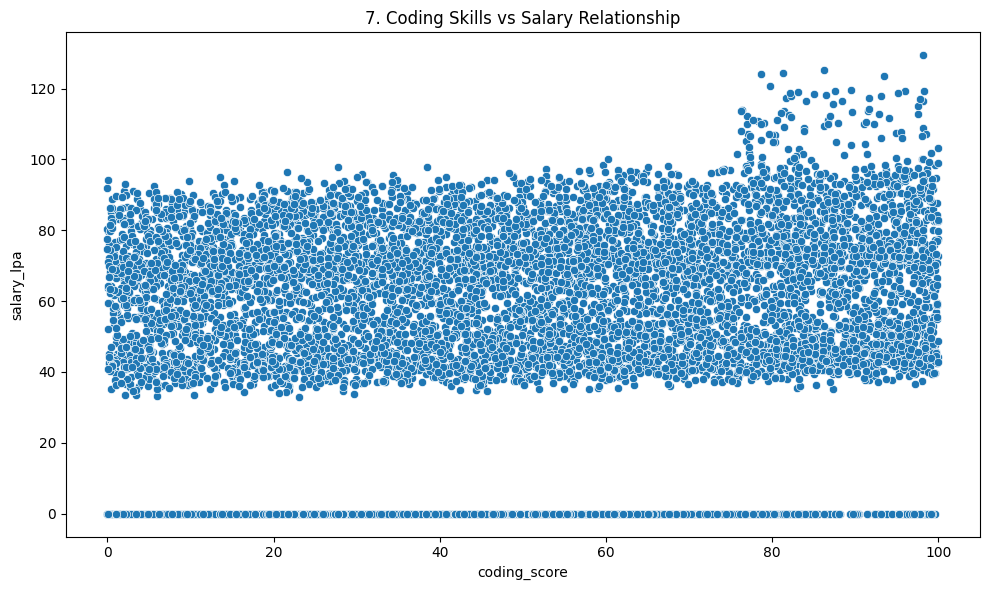

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='coding_score', y='salary_lpa', data=df)
plt.title(f'{plot_no}. Coding Skills vs Salary Relationship')
show_fig()
plot_no += 1

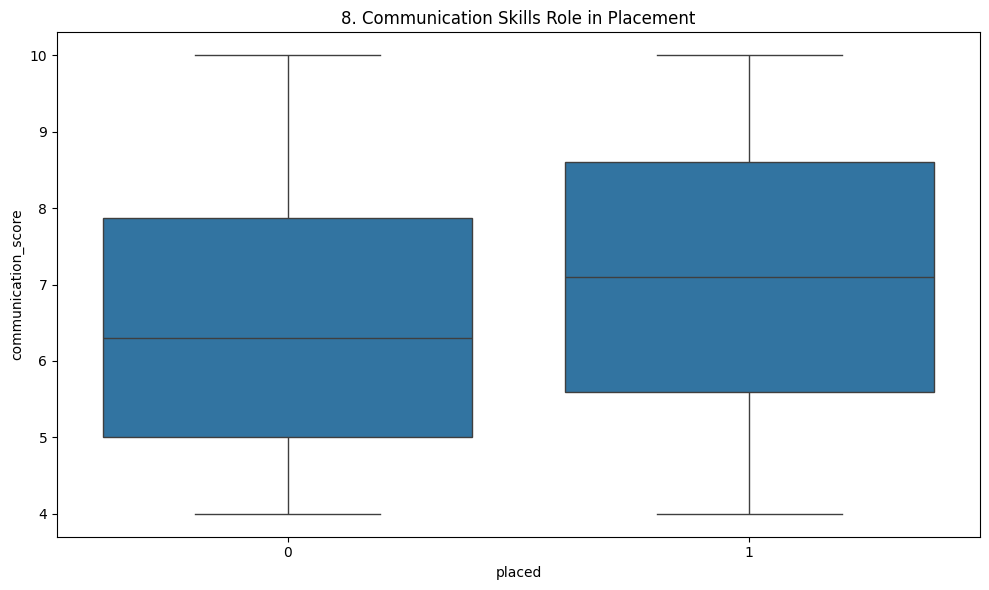

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='placed', y='communication_score', data=df)
plt.title(f'{plot_no}. Communication Skills Role in Placement')
show_fig()
plot_no += 1

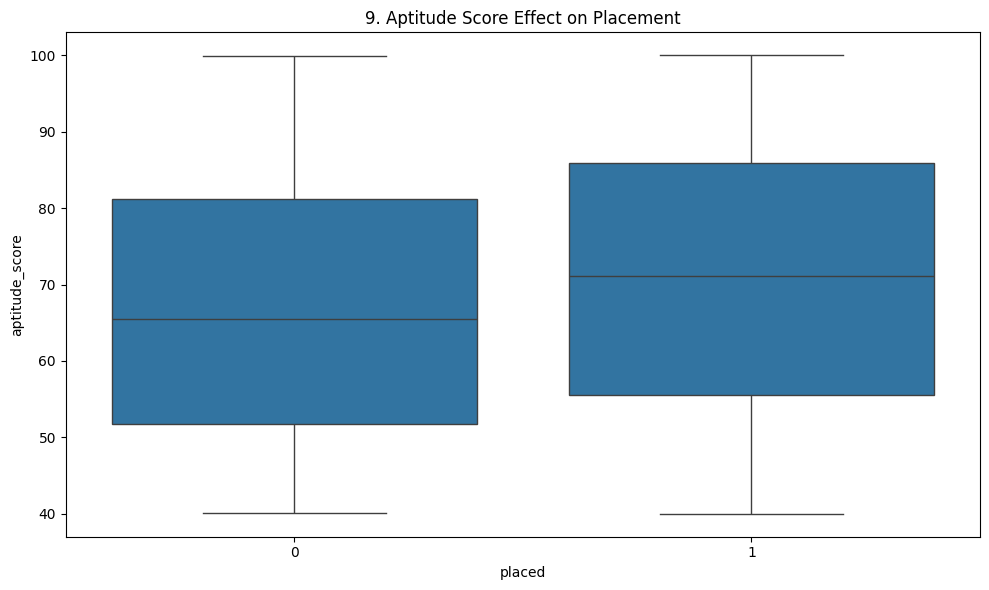

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='placed', y='aptitude_score', data=df)
plt.title(f'{plot_no}. Aptitude Score Effect on Placement')
show_fig()
plot_no += 1

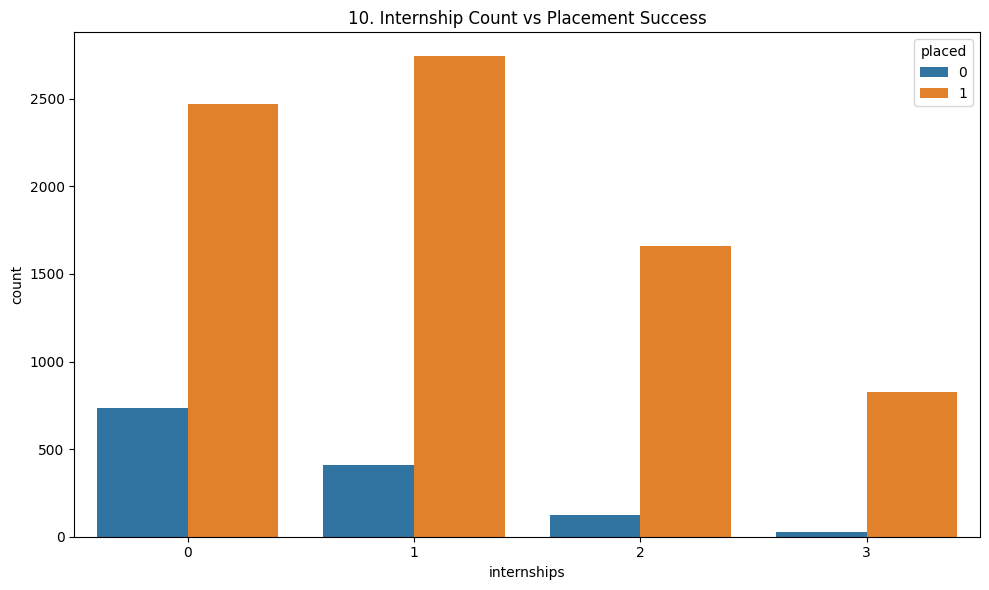

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='internships', hue='placed', data=df)
plt.title(f'{plot_no}. Internship Count vs Placement Success')
show_fig()
plot_no += 1

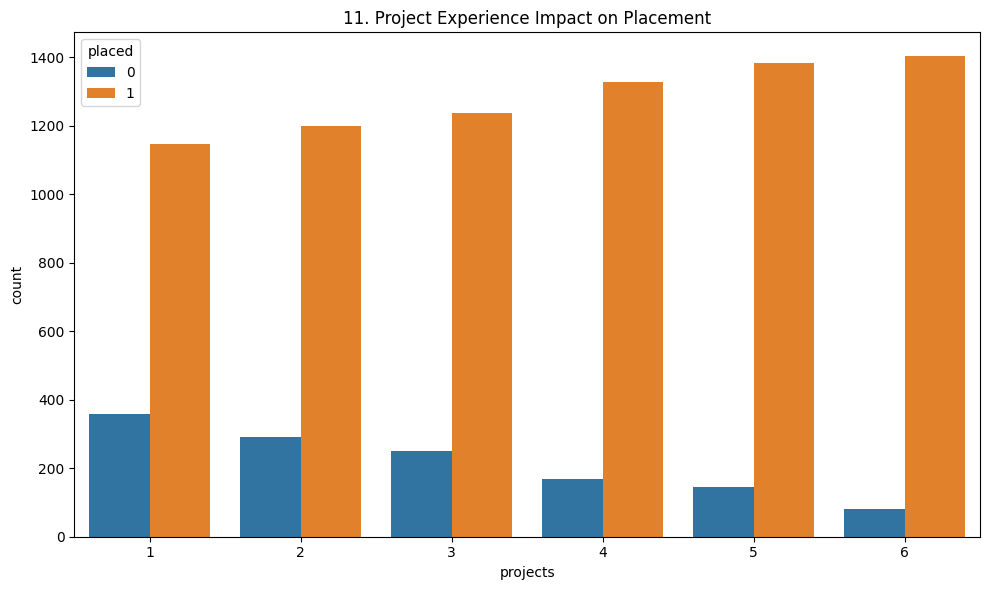

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='projects', hue='placed', data=df)
plt.title(f'{plot_no}. Project Experience Impact on Placement')
show_fig()
plot_no += 1

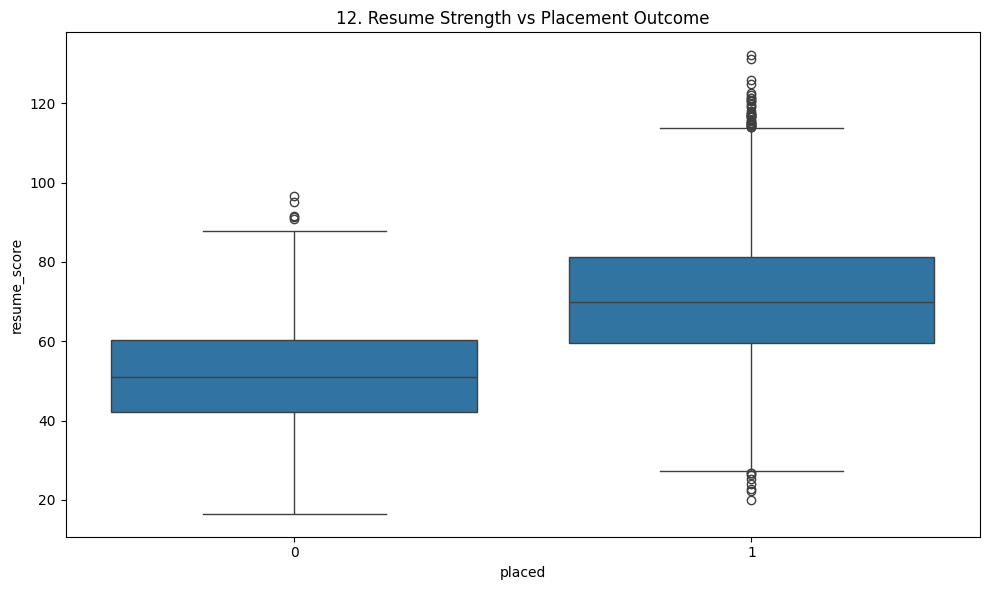

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='placed', y='resume_score', data=df)
plt.title(f'{plot_no}. Resume Strength vs Placement Outcome')
show_fig()
plot_no += 1

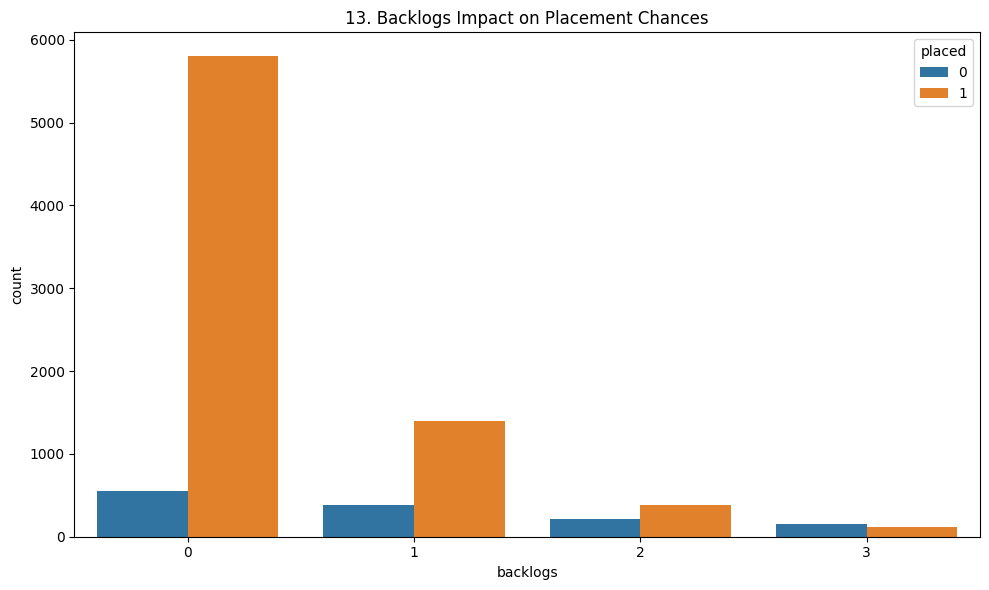

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='backlogs', hue='placed', data=df)
plt.title(f'{plot_no}. Backlogs Impact on Placement Chances')
show_fig()
plot_no += 1

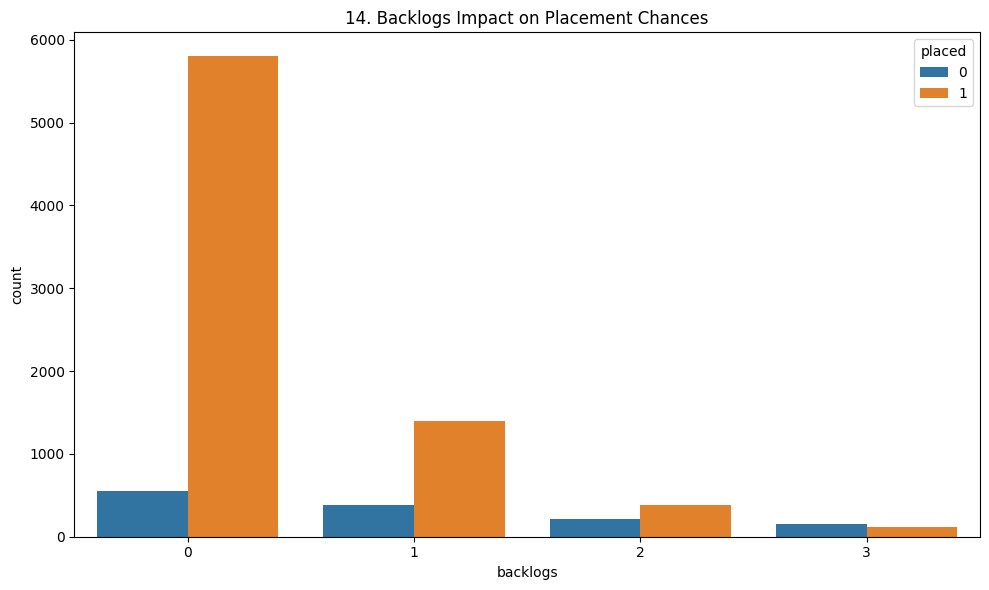

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='backlogs', hue='placed', data=df)
plt.title(f'{plot_no}. Backlogs Impact on Placement Chances')
show_fig()
plot_no += 1

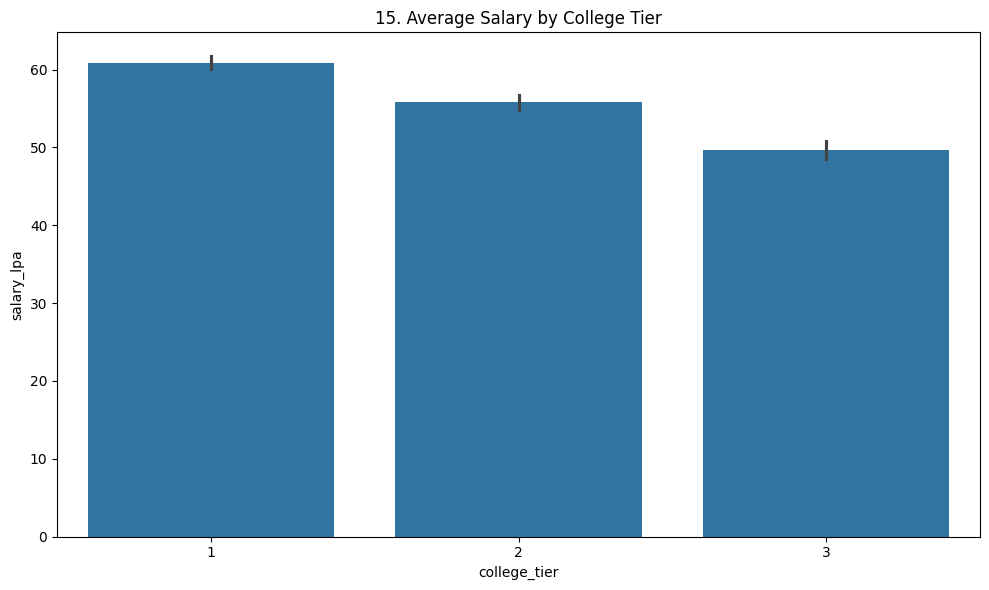

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='college_tier', y='salary_lpa', data=df)
plt.title(f'{plot_no}. Average Salary by College Tier')
show_fig()
plot_no += 1

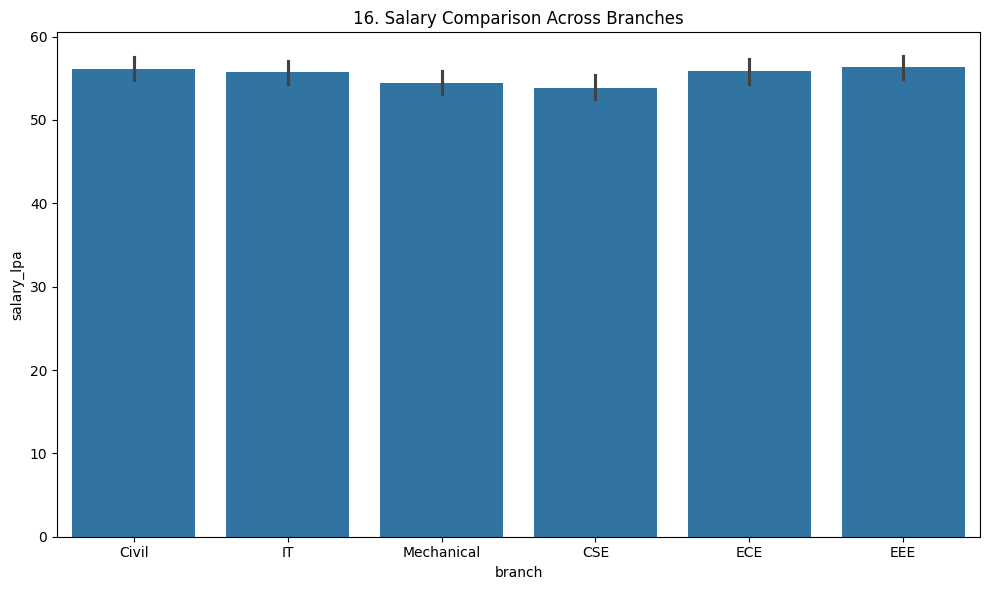

In [29]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='branch', y='salary_lpa', data=df)
plt.title(f'{plot_no}. Salary Comparison Across Branches')
show_fig()
plot_no += 1

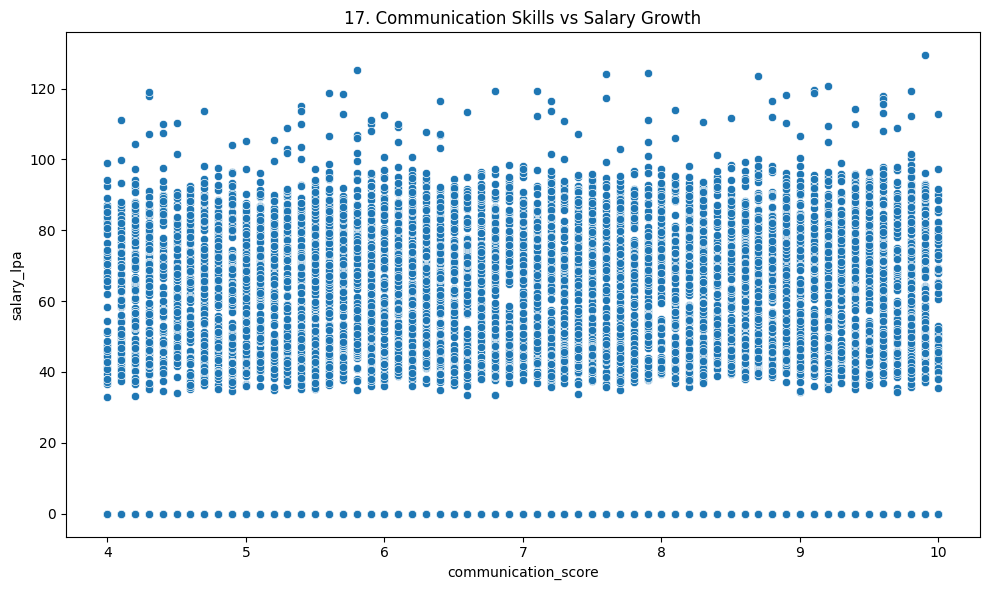

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='communication_score', y='salary_lpa', data=df)
plt.title(f'{plot_no}. Communication Skills vs Salary Growth')
show_fig()
plot_no += 1

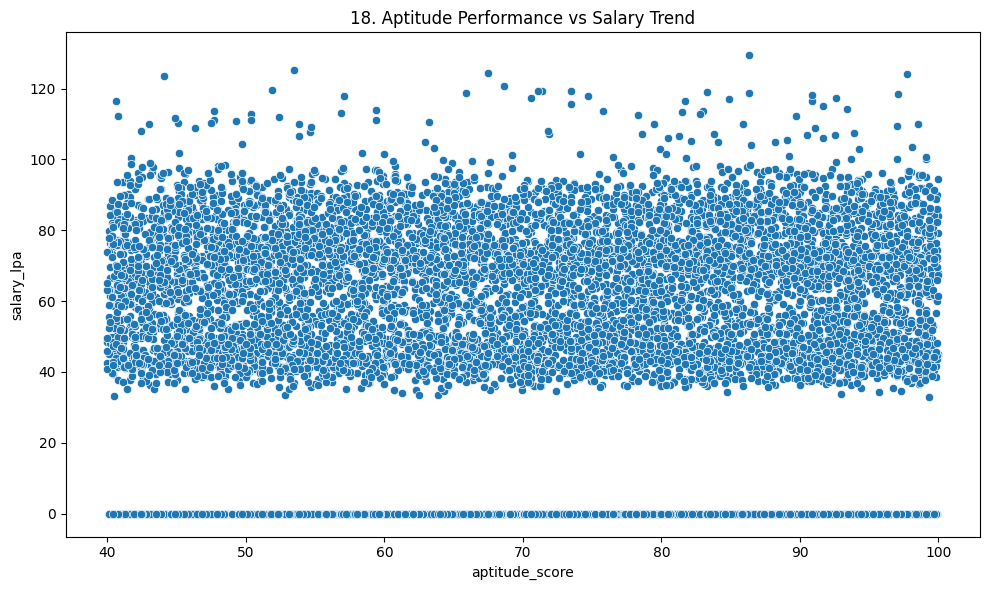

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='aptitude_score', y='salary_lpa', data=df)
plt.title(f'{plot_no}. Aptitude Performance vs Salary Trend')
show_fig()
plot_no += 1

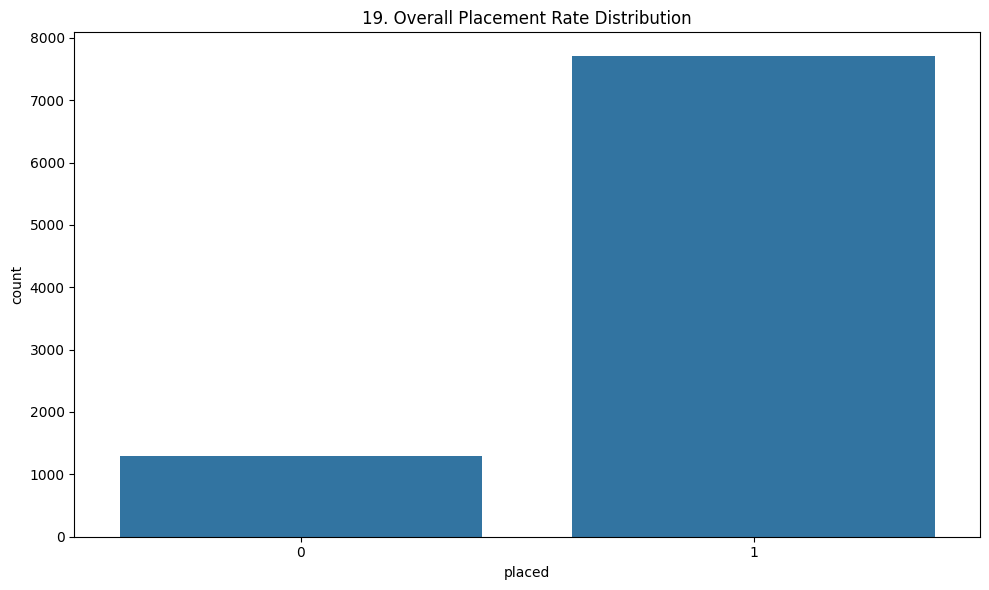

In [32]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='placed', data=df)
plt.title(f'{plot_no}. Overall Placement Rate Distribution')
show_fig()
plot_no += 1

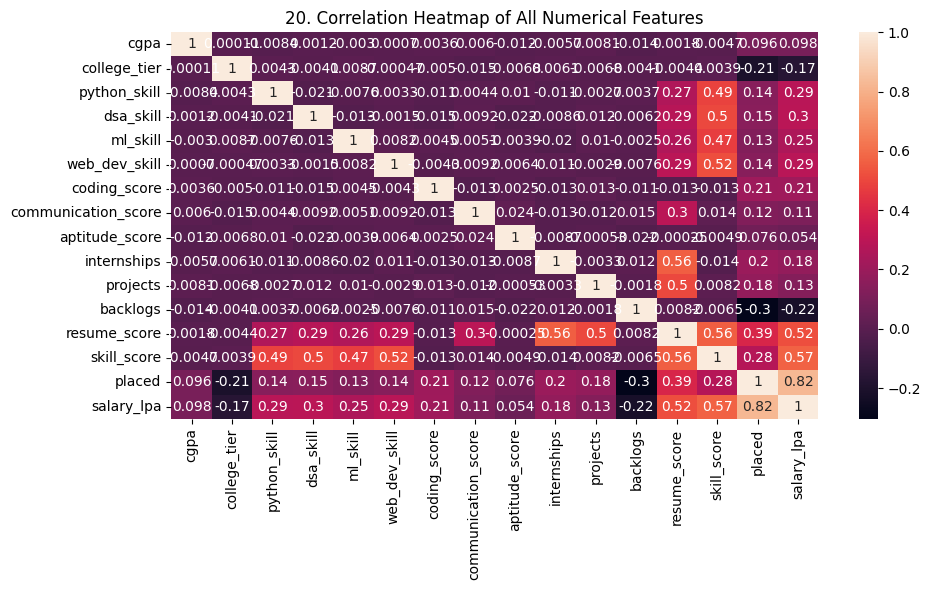

In [33]:
fig = plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of All Numerical Features')
show_fig()
plot_no += 1

# Model Training

## define features and target

In [34]:
X = df.drop(['student_id','salary_lpa','placed'], axis=1)
X = pd.get_dummies(X, drop_first=True)
y = df['placed']

## split the dataset

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scale the features

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train the model

In [37]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## make predictions

In [38]:
y_pred = model.predict(X_test)

## print accuracy

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9227777777777778


## plot confusion matrix

<Figure size 1000x600 with 0 Axes>

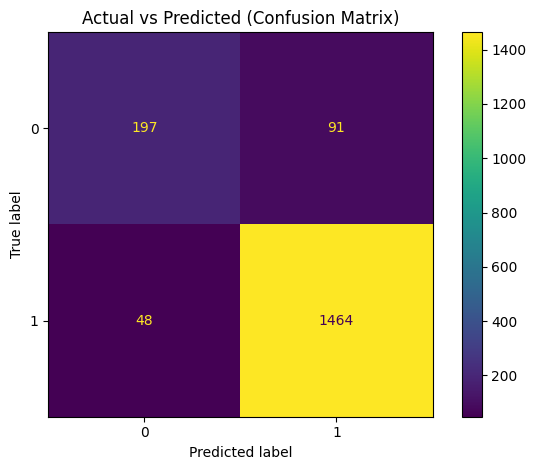

In [40]:
fig = plt.figure(figsize=(10,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Actual vs Predicted (Confusion Matrix)')
show_fig()